# General Information

EMG Signal for gesture recognition

https://www.kaggle.com/datasets/sojanprajapati/emg-signal-for-gesture-recognition/data

Information below taken from kaggle page.

So there are 11 columns. This is a Readme file from the actual dataset.https://archive.ics.uci.edu/ml/datasets/EMG+data+for+gestures

For recording patterns, we used a MYO Thalmic bracelet worn on a user’s forearm, and a PC with a Bluetooth receiver. The bracelet is equipped with eight sensors equally spaced around the forearm that simultaneously acquire myographic signals. The signals are sent through a Bluetooth interface to a PC.
We present raw EMG data for 36 subjects while they performed series of static hand gestures.The subject performs two series, each of which consists of six (seven) basic gestures. Each gesture was performed for 3 seconds with a pause of 3 seconds between gestures.

Description of raw_data _*** file
Each file consist of 10 columns:
1) Time - time in ms;
2-9) Channel - eight EMG channels of MYO Thalmic bracelet;
10) Class –the label of gestures:
0 - unmarked data,
1 - hand at rest,
2 - hand clenched in a fist,
3 - wrist flexion,
4 – wrist extension,
5 – radial deviations,
6 - ulnar deviations,
7 - extended palm (the gesture was not performed by all subjects).

Along with this, I have just added "label" column that refers to the subject who performed the experiment. There were 36 subjects, each performed 7 gestures twice.

**Enabling GPU runtime (necessary)**

Before running this notebook, click edit in the top left, then click notebook settings. Click T4 GPU, then click save. This will enable a GPU runtime, which is needed for running our neural networks

Alternatively, you can click the drop down next to your session resources (located in the top right). Click change runtime time and select T4 GPU.

# Imports and configurations

In [ ]:
import numpy as np
import pandas as pd
import torch
import scipy
from torch.utils.data import TensorDataset as TData
from torch.utils.data import DataLoader as DL
import matplotlib.pyplot as plt

In [ ]:
# checks if cuda is available, then sets device to GPU
if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'
device # should say cuda if gpu is enabled

'cuda'

In [ ]:
# uncomment line below for GPU info
# !nvidia-smi

Get the dataset into colab environment


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving EMG-data.csv to EMG-data.csv


In [ ]:
dataset = pd.read_csv("EMG-data.csv") # loading in the csv dataset with pandas

# Exploratory Data Analysis and Preprocessing

In [ ]:
dataset.head()

,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class,label
0,1,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0,1
1,5,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0,1
2,6,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,1
3,7,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,1
4,8,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,1


In [ ]:
#only interested in all channels and class values that are 1-6 because 0 is unmarked data and not all subjects performed 7

# Keep only rows where class is 1-6
filtered_emg = dataset.loc[dataset['class'].isin([1, 2, 3, 4, 5, 6])]

# Drop unnecessary columns: time
filtered_emg = filtered_emg.drop(columns=['time'])

# Check the result
print(filtered_emg['class'].unique())  # Should show [1 2 3 4 5 6]


[1 2 3 4 5 6]


In [ ]:
filtered_emg.head() #should only have the channels, class and label

,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class,label
2287,-0.00001,0.00000,-0.00001,0.00000,0.00000,-0.00001,-0.00001,0.00001,1,1
2288,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1,1
2289,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1,1
2290,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1,1
2291,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1,1


In [ ]:
#If a subject does gesture 1 twice, you get two separate arrays instead of one big merged array.
#This preserves the temporal structure of each repetition — very important for EMG and LSTMs.
#Separates contiguous sequences of the same class.
#So if a subject performs a gesture twice, you get two separate arrays instead of one big concatenation.
#This is often important for EMG, because signals drift over time, and concatenating two separate repetitions can confuse models (especially LSTMs that look at sequences).

# Get all unique subject IDs from the dataset.
# filtered_emg['label'] holds the subject identifier for each row.
subjects = filtered_emg['label'].unique()   # label = subject ID


# Dictionary to store each subject's EMG blocks.
# Structure:
#   {
#     subject_id: [(class, array), (class, array), ...],
#     ...
#   }
subject_signals = {} #list of signals for each subject in the form subject_signals = {1: [(class, arr), (class, arr), ...], 2: [(class, arr), (class, arr)], ...}

# Process data for each subject individually
for subj in subjects:
    # Extract only the rows corresponding to this subject
    df = filtered_emg[filtered_emg['label'] == subj].copy()  # filter by subject ID

    # create adjacent blocks whenever class changes
    df['block'] = (df['class'] != df['class'].shift()).cumsum()

    # List to store (class, EMG array) pairs for this subject
    subj_blocks = []

    # Iterate through each adjacent gesture block
    for block_id, block_df in df.groupby('block'):

      # Get the gesture class for this block
        cls = block_df['class'].iloc[0]

      # We only keep gesture classes 1–6 (ignore rest/noise/other labels)
        if cls in [1,2,3,4,5,6]:  # valid gesture classes only

            # Extract the 8 EMG channels.
            # block_df.iloc[:, 1:9] means columns 1–8 (assuming EMG channels start at column 1).
            # Convert to numpy and transpose → shape = (8 channels, T samples)
            arr = block_df.iloc[:, 1:9].to_numpy().T  # 8 × T

            # Save the (class, EMG block) tuple
            subj_blocks.append((cls, arr))

    # Store all gesture blocks for this subject
    subject_signals[subj] = subj_blocks


In [ ]:
class_signals = {1:[], 2:[], 3:[], 4:[], 5:[], 6:[]} #make lists for each class

In [ ]:
# Create a dictionary where each gesture class (1–6) maps to an empty list.
# After filling, each class will contain all EMG arrays belonging to that gesture.
class_signals = {c: [] for c in [1,2,3,4,5,6]}

# Iterate through each subject and their list of (class, EMG array) blocks
for subj, blocks in subject_signals.items():
    for class_label, arr in blocks:
        # Append the EMG block to the corresponding class list
        class_signals[class_label].append(arr)

# After this:
#   class_signals[1] contains ALL EMG arrays labeled as gesture 1 (across all subjects)
#   class_signals[2] contains ALL gesture 2 arrays
#   ...
#   class_signals[6] contains ALL gesture 6 arrays

In [ ]:
# Lists to hold (class, signal) pairs for each split
train = []
val = []
test = []

# Fraction of each signal reserved for validation + test.
# Same ratio used in the original sample pipeline.
eval_portion = 0.4  # same as sample pipeline

# Loop over each gesture class 1–6
for c in [1,2,3,4,5,6]:
    signals = class_signals[c] # all EMG arrays for this class

    # Process each individual signal sequence
    for sig in signals:
        seq_len = sig.shape[1] # number of time steps (T)
        eval_len = int(eval_portion * seq_len)  # size of eval window

        # Randomly choose a window inside the signal to hold out for eval/test
        # start ∈ [0, seq_len - eval_len)
        start = np.random.randint(0, seq_len - eval_len)
        end = start + eval_len # end index of the eval window

        # training: remove eval window
        train.append((c, sig[:, list(range(start)) + list(range(end, seq_len))]))

        # validation: first half of eval window
        val.append((c, sig[:, start:start+eval_len//2]))

        # test: second half
        test.append((c, sig[:, start+eval_len//2:end]))

# Signal Preprocessing

In [ ]:
#bandpass filter
def bandpass_filter(signal, crit_freq = [5, 40], sampling_freq = 125):

  # Order of the Butterworth filter (higher = sharper cutoff)
  order = 4

  # Design a Butterworth bandpass filter with critical frequencies (5–40 Hz)
  # fs specifies sampling frequency, so scipy automatically normalizes cutoff
  b, a = scipy.signal.butter(order, crit_freq, btype = 'bandpass', fs = sampling_freq)

  # Apply zero-phase filtering using filtfilt (avoids phase distortion)
  # axis=1 because signals have shape: channels × time
  processed_signal = scipy.signal.filtfilt(b, a, signal, axis = 1)
  return processed_signal

#segmentation
def segmentation(signal, sampling_freq=125, window_size=1, window_shift=0.1):

  # Convert window size (seconds) → number of samples
  w_size = int(sampling_freq * window_size)

  # Convert shift (seconds) → hop length in samples
  w_shift = int(sampling_freq * window_shift)

  segments = [] # List to store the segmented windows
  i = 0 # Sliding window starting index

  # Slide window until the last full window fits in the signal
  while i + w_size <= signal.shape[1]:
    # Extract a window of shape: channels × w_size
    segments.append(signal[:, i: i + w_size])

    # Move the window forward by the shift amount
    i += w_shift
  return segments

#full preprocess method
def preprocess_emg(signal, fs=125, band=[5,40], window_size=1, window_shift=0.1):

    # 1. Bandpass filtering to remove noise and keep muscle-relevant EMG frequencies
    filtered = bandpass_filter(signal, band, fs)

    # 2. Channel-wise z-score normalization:
    #  subtract mean and divide by std for each channel independently
    normed = (filtered - filtered.mean(1, keepdims=True)) / filtered.std(1, keepdims=True)

    # 3. Segment the normalized signal into overlapping windows
    preprocessed = segmentation(normed, fs, window_size, window_shift)
    return preprocessed

In [ ]:
# function to preprocess a dataset of (label, signal) tuples
def preprocess_dataset(dataset, fs=125, band=[5,40], window_size=1, window_shift=0.1):
    processed = []
    for label, sig in dataset:
        segments = preprocess_emg(sig, fs=fs, band=band, window_size=window_size, window_shift=window_shift)
        # attach label to each segment
        processed.extend([(label, seg) for seg in segments])
    return processed

# apply to train, val, test
train_processed = preprocess_dataset(train)
val_processed   = preprocess_dataset(val)
test_processed  = preprocess_dataset(test)

# check results
print(f"Train segments: {len(train_processed)}, Val segments: {len(val_processed)}, Test segments: {len(test_processed)}")
print(f"Segment shape: {train_processed[0][1].shape}")  # [1] gives the NumPy array


Train segments: 66456, Val segments: 16429, Test segments: 16455
Segment shape: (8, 125)


# Creating Data Loaders

In [ ]:
import torch
from torch.utils.data import TensorDataset as TData, DataLoader as DL

num_classes = 6  # gestures 1-6

# create torch tensor of zeros to hold data
train_emg_tensor = torch.zeros((len(train_processed), train_processed[0][1].shape[0], train_processed[0][1].shape[1]))
val_emg_tensor   = torch.zeros((len(val_processed), val_processed[0][1].shape[0], val_processed[0][1].shape[1]))
test_emg_tensor  = torch.zeros((len(test_processed), test_processed[0][1].shape[0], test_processed[0][1].shape[1]))

# add each sample in train, validation, and test lists to appropriate tensor at correct index
for i, (label, seg) in enumerate(train_processed):
    train_emg_tensor[i] = torch.from_numpy(seg.copy())
for i, (label, seg) in enumerate(val_processed):
    val_emg_tensor[i] = torch.from_numpy(seg.copy())
for i, (label, seg) in enumerate(test_processed):
    test_emg_tensor[i] = torch.from_numpy(seg.copy())

# create zero tensor for one hot encoded labels
train_label_tensor = torch.zeros(len(train_processed), num_classes)
val_label_tensor   = torch.zeros(len(val_processed), num_classes)
test_label_tensor  = torch.zeros(len(test_processed), num_classes)

# add labels to tensor at correct index
for i, (label, seg) in enumerate(train_processed):
    train_label_tensor[i][label-1] = 1  # subtract 1 if labels are 1-indexed
for i, (label, seg) in enumerate(val_processed):
    val_label_tensor[i][label-1] = 1
for i, (label, seg) in enumerate(test_processed):
    test_label_tensor[i][label-1] = 1

# convert input, target tensors to Tensor Dataset from torch
train_ds = TData(train_emg_tensor, train_label_tensor)
val_ds   = TData(val_emg_tensor, val_label_tensor)
test_ds  = TData(test_emg_tensor, test_label_tensor)
# create dataloaders to hold batched data (batch size chosen was 64)
batch_size = 64
train_dl = DL(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_dl   = DL(val_ds, batch_size=batch_size, shuffle=True, drop_last=True)
test_dl  = DL(test_ds, batch_size=batch_size, shuffle=True, drop_last=True)

#check
print(f'Train batches: {len(train_dl)}, Val batches: {len(val_dl)}, Test batches: {len(test_dl)}')
print(f'Sample shape: {train_emg_tensor[0].shape}, Label shape: {train_label_tensor[0].shape}')


Train batches: 1038, Val batches: 256, Test batches: 257
Sample shape: torch.Size([8, 125]), Label shape: torch.Size([6])


# CNN LSTM Model

In [ ]:
import torch
import torch.nn as nn

class CNNLSTMFeatureFusionModel(nn.Module):
    def __init__(self, in_channels, n_classes, hidden_units=50):
        super().__init__()

        # CNN branch
        # First convolution layer: 8 → 16 channels, kernel=7
        # padding='same' keeps time length unchanged
        self.conv1 = nn.Conv1d(in_channels, 16, kernel_size=7, padding='same')
        self.conv1_bn = nn.BatchNorm1d(16)
        self.pool1 = nn.AvgPool1d(2) # halves the time dimension

        # Depthwise + Pointwise (Separable Convolution):
        # Depthwise conv: 16 groups → each channel filtered independently
        # Pointwise conv: 1×1 conv mixes channels → 24 output channels
        self.separable_conv = nn.Sequential(
            nn.Conv1d(16, 16, kernel_size=3, groups=16, padding='same'),  # depthwise convolution
            nn.Conv1d(16, 24, kernel_size=1),  # pointwise convolution (channel mixing)
            nn.BatchNorm1d(24),
            nn.ReLU(),
            nn.AvgPool1d(2)  # halves time dimension again
        )


        # Flatten CNN output to 1D vector
        self.flatten_cnn = nn.Flatten()

        # LSTM branch
        # Input size = number of channels (8)
        # Hidden size = LSTM embedding dimension
        # batch_first=True → input expected as (batch, seq_len, channels)
        self.lstm = nn.LSTM(input_size=in_channels, hidden_size=hidden_units, batch_first=True)

         # Flatten LSTM output after selecting last time step
        self.flatten_lstm = nn.Flatten()

        # Fully connected layer for fusion
        self.dropout = nn.Dropout(0.5)

        # Fully-connected layer receives concatenated CNN + LSTM embeddings
        # CNN output size = 24 * 31   (depends on window length + pooling)
        # LSTM output size = hidden_units
        self.fc = nn.Linear(24*31 + hidden_units, n_classes)  # Updated input size

    def forward(self, x):
        # CNN branch
        cnn_out = self.conv1(x)
        cnn_out = self.conv1_bn(cnn_out)
        cnn_out = self.pool1(cnn_out)
        cnn_out = self.separable_conv(cnn_out)
        cnn_out = self.flatten_cnn(cnn_out) # shape → (batch, CNN_features)

        # LSTM branch
        # LSTM expects (batch, seq_len, channels), so permute:
        # input x is (batch, channels, seq_len)
        lstm_input = x.permute(0, 2, 1)  # (batch, seq len, channels)

        # LSTM returns outputs for every time step
        lstm_out, _ = self.lstm(lstm_input)
        lstm_out = lstm_out[:, -1, :]  # Last time step’s output
        lstm_out = self.flatten_lstm(lstm_out) # shape → (batch, hidden_units)

        # Concatenate CNN and LSTM outputs
        fused_out = torch.cat((cnn_out, lstm_out), dim=1)

        # Apply dropout and final linear layer
        fused_out = self.dropout(fused_out)
        output = self.fc(fused_out)

        return output


# Example usage
fusion_model = CNNLSTMFeatureFusionModel(in_channels=8, n_classes=6).to(device)

# Model Training

In [ ]:
from tqdm.auto import tqdm
# using cross_entropy_loss
criterion = torch.nn.CrossEntropyLoss()
# using SGD optimizer for optimal convergence, even if slower
optimizer = torch.optim.Adam(fusion_model.parameters(), lr = 1e-4, weight_decay=1e-5)
epochs = 75

train_losses = []
val_losses = []
accs = []
max_acc = 0
for i in range(epochs):
  total_train_loss = 0.0
  # set model to training mode
  fusion_model.train()
  # create progress bar
  pbar = tqdm(total=len(train_dl))
  for j, (sig, labels) in tqdm(enumerate(train_dl)):
    # add signal and label to cuda device
    sig = sig.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    # forward pass
    pred = fusion_model(sig)
    # loss evaluation
    loss = criterion(pred, labels)
    # backpropagation
    loss.backward()
    optimizer.step()

    total_train_loss += loss.item()
    # update progress bar with running loss
    pbar.set_description(f"Epoch {i + 1}    loss={total_train_loss / (j + 1):0.4f}")
    pbar.update(1)
  pbar.close()
  train_losses.append(total_train_loss / len(train_dl))

  total_val_loss = 0.0
  total_accuracy = 0.0
  # set model to evaluation mode, which changes the behavior
  # of some layers like dropout and batch normalization
  fusion_model.eval()
  with torch.no_grad():
      # create progress bar
      pbar = tqdm(total=len(val_dl))
      for j, (sig, labels) in enumerate(val_dl):
          # send signal and label to cuda device
          sig = sig.to(device)
          labels = labels.to(device)
          # make prediction and evaluate loss
          pred = fusion_model(sig)
          loss = criterion(pred, labels)

          # perform softmax on output which is usually performed by loss automatically
          # this gives a probability vector
          prob_pred = torch.nn.functional.softmax(pred, -1)
          # compute accuracies by
          # 1. getting index of highest number (highest probability prediction)
          # 2. comparing the tensors element wise which gives boolean array comparing predictions to ground truth
          # 3. converting boolean array into array of 0s and 1s
          # 4. calculating mean with binary array, which gives (correct predictions) / (total predictions)
          acc = (prob_pred.argmax(-1) == labels.argmax(-1)).float().mean()
          total_val_loss += loss.item()
          total_accuracy += acc.item()

          # update progress bar with val loss and accuracy
          pbar.set_description(f"val loss={total_val_loss / (j + 1):.4f}    val acc={total_accuracy / (j + 1):.4f}")
          pbar.update(1)
      print()
      pbar.close()
      val_losses.append(total_val_loss / len(val_dl))
      accs.append(total_accuracy / len(val_dl))

  # save model if accuracy is best seen
  if accs[-1] > max_acc:
    # dictionary with model state dict, optimizer state dict, and best accuracy
    checkpoint = {'state_dict': fusion_model.state_dict(), 'optimizer': optimizer.state_dict(), 'best_acc': accs[-1]}
    # save dictionary to specified file path if it exists or create new one otherwise
    torch.save(checkpoint, 'SepConv2.pth.tar')
    print('Model Saved')
    max_acc = accs[-1]

  0%|          | 0/1038 [00:00<?, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]


Model Saved


  0%|          | 0/1038 [00:00<?, ?it/s]

...

0it [00:00, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/1038 [00:00<?, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

# Model Evaluation

In [ ]:
# loading most accurate model
ckpt_dict = torch.load('SepConv2.pth.tar', weights_only=True)
fusion_model.load_state_dict(ckpt_dict['state_dict'])
# setting model to evaluation mode
fusion_model.eval()
test_accuracy = 0.0
test_loss = 0.0
with torch.no_grad():
      for signal, labels in test_dl:
          # send signal and label to cuda device
          signal = signal.to(device)
          labels = labels.to(device)
          # make prediction and evaluate loss
          pred = fusion_model(signal)
          loss = criterion(pred, labels)
          # compute probability vector and accuracy
          prob_pred = torch.nn.functional.softmax(pred, -1)
          acc = (prob_pred.argmax(-1) == labels.argmax(-1)).float().mean()
          test_loss += loss.item()
          test_accuracy += acc.item()

# display test set loss and accuracy
print(f'Test set    loss: {test_loss / len(test_dl):.4f}    accuracy: {test_accuracy / len(test_dl):.4f}')

Test set    loss: 0.9112    accuracy: 0.5979


Text(0, 0.5, 'cross entropy loss')

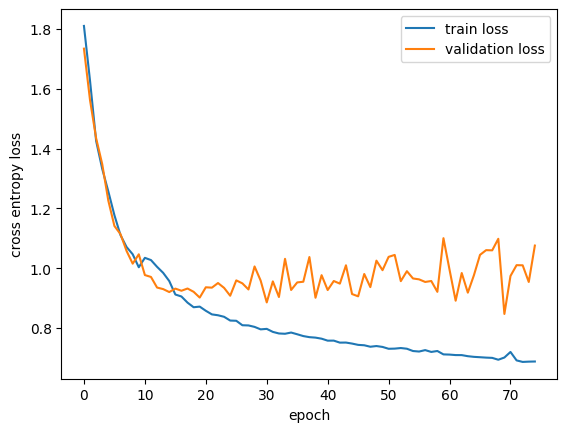

In [ ]:
# plotting train and validation loss
plt.plot(train_losses, label = 'train loss')
plt.plot(val_losses, label = 'validation loss')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('cross entropy loss')

Text(0, 0.5, 'accuracy')

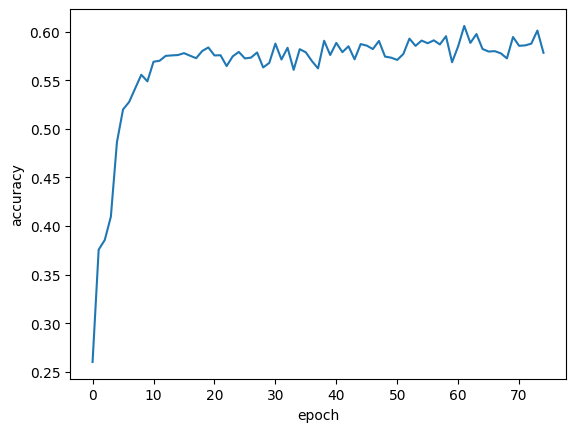

In [ ]:
# plotting validation accuracy
plt.plot(accs)
plt.xlabel('epoch')
plt.ylabel('accuracy')

These graphs show us how our model begins to overfit around epoch 15 due to how validation loss starts fluctuating and slowly rising while training loss continues to drop smoothly and diverge from it. Up until then, both training loss and validation loss go down together showing normal learning.